## This notebook is for visualizing the diversity of the training set (such as distributional plots)

In [1]:
import os
import pandas as pd
import numpy as np
import skimage
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

- Count number of micronuclei annotations per each dataset

In [3]:
path = '/scr/yren/annotated_mn_datasets/'
df = pd.read_csv(os.path.join(path, 'metadata.csv'))
df = df[df.split == 'train'] # only draw training set
df.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.50,train,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.50,train,RPE1
6,20X_c0-DAPI_A1_Tile-190.tif,mnDINO_data_01,14,4.25,train,HeLa
7,C2-20X_c0-DAPI-GFP_B2_Tile-20.tif,mnDINO_data_01,14,4.25,train,HeLa
11,20X_c0-DAPI_A1_Tile-90.tif,mnDINO_data_01,14,4.25,train,HeLa


In [8]:
df_sub = df.loc[df.split == 'train', ['filenames', 'datasets']].copy().reset_index()
train_mn_mask_path = os.path.join(path, 'train', 'mn_masks')

for i in range(df_sub.shape[0]):
    mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_sub.loc[i, 'filenames'].replace('.tif', '.png')))
    labels = skimage.measure.label(mn_mask)
    num_of_mn = np.max(labels) # maximal label is the total number of micronuclei
    df_sub.loc[i, 'num_of_mn'] = num_of_mn

['mnDINO_data_02', 'mnDINO_data_01', 'mnfinder_train', 'BBBC039']
152.0
1024.0
1749.0
799.0


Text(0.5, 1.0, 'Distribution of Number of Micronuclei')

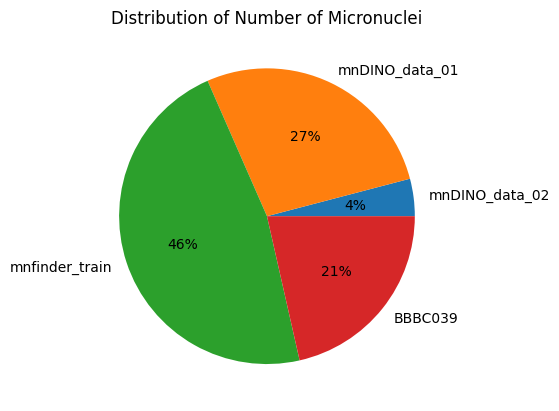

In [19]:
labels = df_sub.datasets.unique().tolist()
print(labels)
counts = []

for subset in labels:
    total_mn = df_sub.loc[df_sub.datasets == subset, 'num_of_mn'].sum()
    print(total_mn)
    counts.append(total_mn)
    
plt.pie(x = counts, labels=labels, autopct='%d%%')
plt.title('Distribution of Number of Micronuclei')

# Histogram of mn size v.s. nuclei size for each subset

In [13]:
labels = sorted(df[df.split == 'train'].datasets.unique().tolist())
print(labels)
mn_areas = []
nuclei_areas = []

for label in labels:
    df_train = df.loc[(df.split == 'train') & (df.datasets == label), ['filenames', 'datasets']].copy().reset_index()
    train_mn_mask_path = os.path.join(path, 'train', 'mn_masks')
    train_nuclei_mask_path = os.path.join(path, 'train', 'nuclei_masks')

    
    mn_area_lst = []
    nuc_area_lst = []
    for i in range(df_train.shape[0]):
        mn_mask = skimage.io.imread(os.path.join(train_mn_mask_path, df_train.loc[i, 'filenames'].replace('.tif', '.png')))
        nuc_mask = skimage.io.imread(os.path.join(train_nuclei_mask_path, df_train.loc[i, 'filenames']))

        mn_labels = skimage.measure.label(mn_mask)
        nuc_labels = skimage.measure.label(nuc_mask)
        
        
        for mn_id in range(1, np.max(mn_labels) + 1):
            mn_area = np.sum(mn_labels == mn_id)
            mn_area_lst.append(mn_area)
        
        for nuc_id in range(1, np.max(nuc_labels) + 1):
            nuc_area = np.sum(nuc_labels == nuc_id)
            nuc_area_lst.append(nuc_area)
            
    mn_areas.append(mn_area_lst)
    nuclei_areas.append(nuc_area_lst)
        

['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02', 'mnfinder_train']


In [14]:
print(len(mn_areas))
print(len(nuclei_areas))

print(mn_areas[0])
print(mn_areas[1])

print(nuclei_areas[0])
print(nuclei_areas[1])

4
4
[np.int64(85), np.int64(12), np.int64(12), np.int64(17), np.int64(17), np.int64(16), np.int64(9), np.int64(84), np.int64(16), np.int64(81), np.int64(96), np.int64(35), np.int64(14), np.int64(20), np.int64(12), np.int64(87), np.int64(16), np.int64(15), np.int64(27), np.int64(56), np.int64(75), np.int64(13), np.int64(15), np.int64(95), np.int64(19), np.int64(89), np.int64(82), np.int64(81), np.int64(62), np.int64(13), np.int64(19), np.int64(33), np.int64(12), np.int64(48), np.int64(20), np.int64(12), np.int64(12), np.int64(12), np.int64(89), np.int64(20), np.int64(20), np.int64(12), np.int64(12), np.int64(27), np.int64(29), np.int64(99), np.int64(12), np.int64(40), np.int64(26), np.int64(21), np.int64(95), np.int64(38), np.int64(16), np.int64(45), np.int64(12), np.int64(14), np.int64(21), np.int64(38), np.int64(110), np.int64(31), np.int64(12), np.int64(2), np.int64(82), np.int64(67), np.int64(36), np.int64(41), np.int64(26), np.int64(33), np.int64(26), np.int64(12), np.int64(15), np

(array([ 11.,   9.,  11.,  10.,  13.,  16.,   5.,  13.,  15.,  21.,  25.,
         30.,  44.,  55.,  75.,  72.,  75., 104., 117., 106.,  85.,  93.,
        104.,  99.,  69.,  67.,  65.,  51.,  58.,  45.,  49.,  38.,  34.,
         35.,  21.,  32.,  21.,  26.,  19.,  15.,  19.,  13.,  19.,  12.,
         12.,  17.,  10.,  19.,   9.,  11.,   5.,  15.,  11.,   7.,  12.,
          6.,   8.,   6.,   3.,   5.,   9.,   4.,   3.,   7.,   3.,   1.,
          6.,   3.,   3.,   5.,   2.,   1.,   1.,   1.,   5.,   1.,   1.,
          3.,   2.,   5.,   3.,   2.,   2.,   0.,   3.,   2.,   0.,   0.,
          2.,   2.,   0.,   2.,   0.,   0.,   0.,   2.,   2.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   0.,   0.,   0.,
          1.,   0.,   2.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0., 

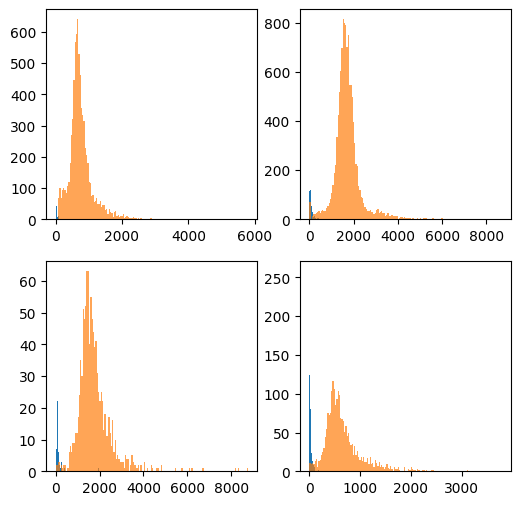

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(6,6))

idx = 0
axs[idx,idx].hist(mn_areas[idx], bins=100, label='micronuclei')
axs[idx,idx].hist(nuclei_areas[idx], bins=150, label='nuclei', alpha=0.7)
axs[idx,idx].axis('off')
axs[idx,idx].legend(loc='upper right')
axs[idx,idx].set_xlim((0,3000))

axs[idx,idx+1].hist(mn_areas[idx+1], bins=100, label='micronuclei')
axs[idx,idx+1].hist(nuclei_areas[idx+1], bins=150, label='nuclei', alpha=0.7)

axs[idx+1,idx].hist(mn_areas[idx+2], bins=100, label='micronuclei')
axs[idx+1,idx].hist(nuclei_areas[idx+2], bins=150, label='nuclei', alpha=0.7)

axs[idx+1,idx+1].hist(mn_areas[idx+3], bins=100, label='micronuclei')
axs[idx+1,idx+1].hist(nuclei_areas[idx+3], bins=150, label='nuclei', alpha=0.7)

In [22]:
for i, ax in enumerate(axs.flat):
    print(i,ax)

0 Axes(0.025,0.5125;0.4625x0.4625)
1 Axes(0.5125,0.5125;0.4625x0.4625)
2 Axes(0.025,0.025;0.4625x0.4625)
3 Axes(0.5125,0.025;0.4625x0.4625)


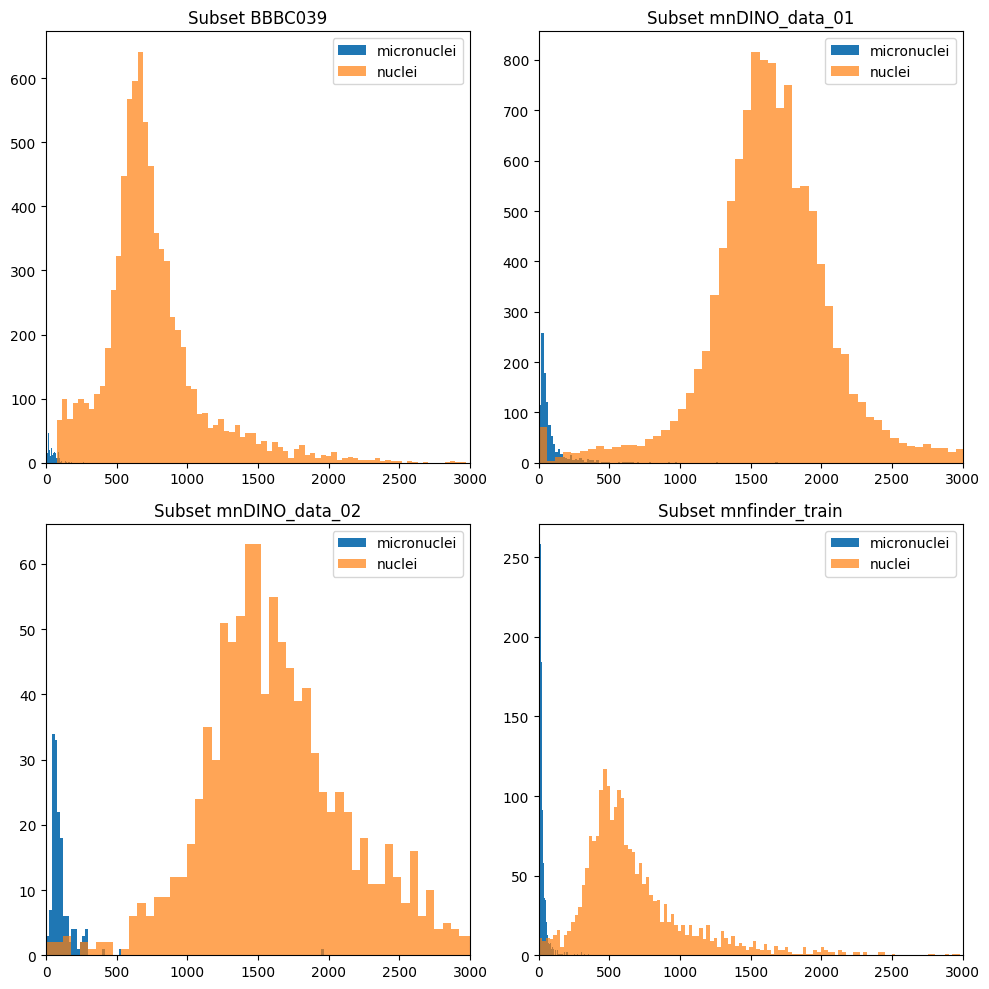

In [26]:
labels = sorted(df[df.split == 'train'].datasets.unique().tolist())
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Use enumerate and axs.flat to loop through a single flattened list of axes
for i, ax in enumerate(axs.flat):
    # Check if there is data for the current index to avoid errors
    # if i < len(mn_areas) and i < len(nuclei_areas):
    ax.hist(mn_areas[i], bins=100, label='micronuclei')
    ax.hist(nuclei_areas[i], bins=150, label='nuclei', alpha=0.7)
    ax.legend(loc='upper right')
    ax.set_xlim((0, 3000))
    ax.set_title(f'Subset {labels[i]}')
    # ax.axis('off') 

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

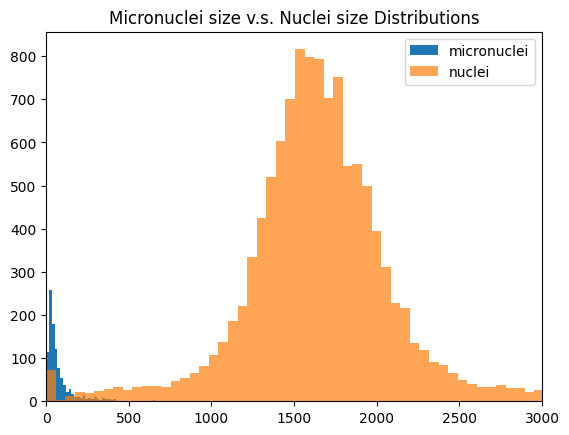

In [16]:
plt.hist(mn_areas[1], bins=100, label='micronuclei')
plt.hist(nuclei_areas[1], bins=150, label='nuclei', alpha=0.7)
plt.title('Micronuclei size v.s. Nuclei size Distributions')
plt.legend(loc='upper right')
plt.xlim((0, 3000))
plt.show()